<a href="https://colab.research.google.com/github/adhibgs/data-science-2025/blob/main/Pertemuan4_Adhi_Bagus_May_Maulana_250401020116.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pertemuan ke-4

*   Nama : Adhi Bagus May Maulana
*   NIM : 250401020116
*   Kelas : IF405   

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df=sns.load_dataset('iris')
print ('Shape:', df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(3))

Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

In [ ]:
for col_name in df.select_dtypes(include='number').columns:
  col = df[col_name]
  print (f'\n=== {col_name} ===')
  print(f'Mean: {col.mean():.3f}')
  print(f'Median: {col.median():.3f}')
  print(f'Std Dev: {col.std():.3f}')
  print(f'Skewness: {col.skew():.3f}')
  print(f'Kurtosis: {col.kurt():.3f}')


=== sepal_length ===
Mean: 5.843
Median: 5.800
Std Dev: 0.828
Skewness: 0.315
Kurtosis: -0.552

=== sepal_width ===
Mean: 3.057
Median: 3.000
Std Dev: 0.436
Skewness: 0.319
Kurtosis: 0.228

=== petal_length ===
Mean: 3.758
Median: 4.350
Std Dev: 1.765
Skewness: -0.275
Kurtosis: -1.402

=== petal_width ===
Mean: 1.199
Median: 1.300
Std Dev: 0.762
Skewness: -0.103
Kurtosis: -1.341


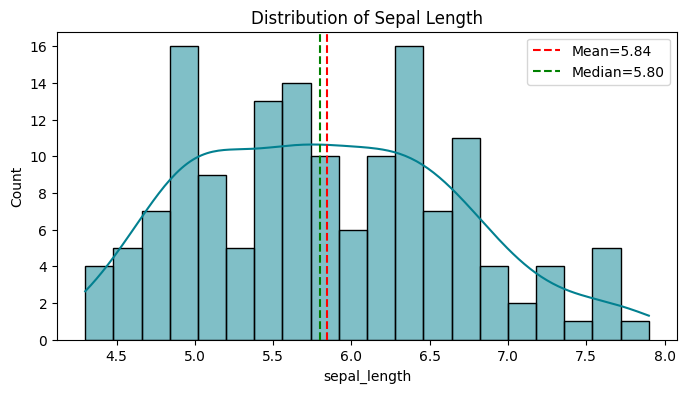

In [ ]:
fig, ax=plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red', linestyle='--',label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='green', linestyle='--',label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribution of Sepal Length')
ax.legend()
plt.show()


/tmp/ipykernel_2418/3020331918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot (data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
/tmp/ipykernel_2418/3020331918.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])


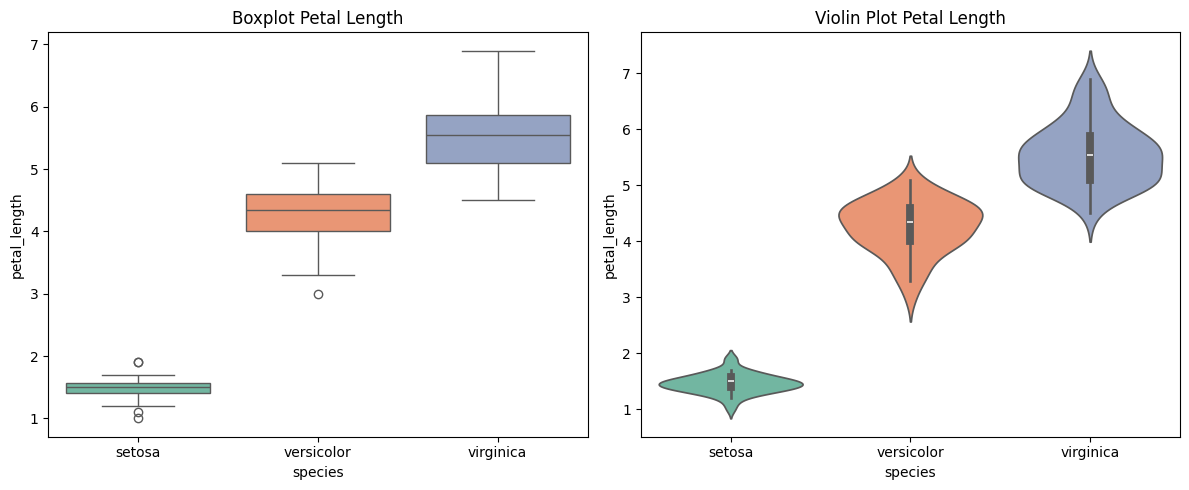

In [ ]:
fig, axes=plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot (data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Petal Length')
sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')
plt.tight_layout()
plt.show()

In [ ]:
corr =df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

import numpy as np
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked=corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair}={corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length')=0.963


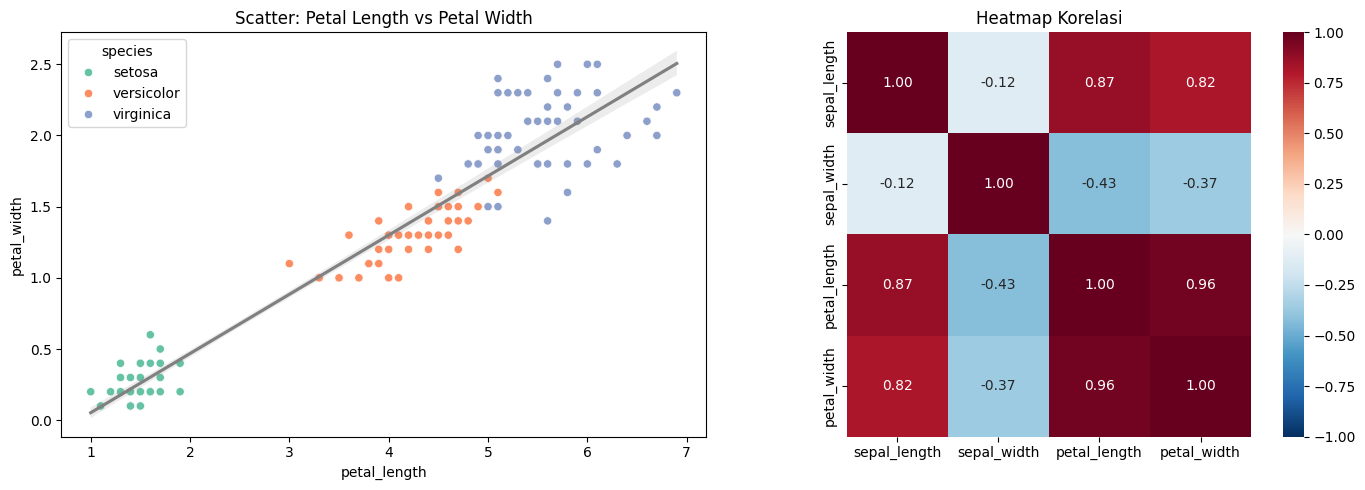

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width',
 hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width',
 scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
 vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')
plt.tight_layout(); plt.show()


KESIMPULAN

Dari praktik pertemuan 4 kita dapat ambil kesimpulan bahwa kita dapat mengambil nilai Mean, Median, Standard Deviasi Skewness, dan Kurtosis dalam data sheet iris. kemudian kita dapat menampilkan Visualisasi Distribusi Tunggal, Visualisasi Karakteristik Antar Kelompok, dan Analisis Korelasi Linier Antar Variabel.